# Import data from UCI Machine Learning Repository
### Dataset: Online Retail
https://archive.ics.uci.edu/dataset/352/online+retail

In [44]:
pip install ucimlrepo

In [45]:
from ucimlrepo import fetch_ucirepo 
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
  
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 
  
# data (as pandas dataframes) 
df = online_retail.data.original 

In [46]:
df.shape

(541909, 8)

# Data Cleaning
Using SQL to clean data to demonstrate capability

In [47]:
# Filtering dataset
df = duckdb.sql(
    """
    WITH main_unfiltered AS(
        SELECT
            Description                                                                             AS description,
            Quantity                                                                                AS quantity,
            CAST(STRPTIME(InvoiceDate, '%m/%d/%Y %H:%M') AS DATE)                                   AS invoice_date,
            UnitPrice                                                                               AS unit_price,
            CAST(CustomerID AS STRING)                                                              AS customer_id,
            Country                                                                                 AS country,
            InvoiceNo                                                                               AS invoice_number,
            MAX(CAST(STRPTIME(InvoiceDate, '%m/%d/%Y %H:%M') AS DATE)) OVER ()                      AS global_max_date
        FROM
            df
    ),

    main AS (
        SELECT
            *
        FROM
            main_unfiltered
        WHERE
            invoice_date < DATE_ADD(global_max_date, INTERVAL '-3 MONTH') -- Filter out the last 90 days, this will be used for target variables
            AND description = UPPER(description) -- Filtering to just Products, Products are capitalised and adjustments such as discounts are lowercase
    ),

    max_invoice_date AS (
        SELECT
            MAX(invoice_date) AS max_date
        FROM 
            main
    ),

    customer_lifespan AS (
        SELECT
            customer_id,
            DATEDIFF('day', MIN(invoice_date), MAX(invoice_date)) AS customer_lifespan_days,
            COUNT(DISTINCT invoice_number) AS life_time_orders,
            SUM(quantity*unit_price) AS total_spend, 
            MAX(invoice_date) AS last_order_date 
        FROM
            main
        WHERE
            customer_id IS NOT NULL
        GROUP BY
            customer_id
    ),

    discount AS (
        SELECT
            customer_id,
            invoice_date,
            SUM(quantity*unit_price) AS discount,
            COUNT(invoice_number) AS number_of_discounts 
        FROM
            main_unfiltered
        WHERE
            description = 'Discount'
            AND invoice_date < DATE_ADD(global_max_date, INTERVAL '-3 MONTH')
        GROUP BY
            customer_id, 
            invoice_date
    ),

    returns AS (
        SELECT
            customer_id,
            SUM(quantity) *-1                   AS units_returned,
            SUM(quantity*unit_price) *-1        AS total_returns_value,
            COUNT(Distinct invoice_date)        AS number_of_orders_returned
        FROM
            main
        WHERE
            quantity < 0 -- Negative quantities are returned orders
        GROUP BY
            customer_id

    ),

    target_variable AS (
        SELECT DISTINCT
            customer_id,
            0 as customer_churned
        FROM 
            main_unfiltered
        WHERE
            invoice_date >= DATE_ADD(global_max_date, INTERVAL '-3 MONTH') -- Filter to the last 90 days of data
    ),
    
    final AS (
        SELECT 
            a.customer_id,
            SUM(a.quantity * a.unit_price)                                              AS total_spend,
            MAX(b.customer_lifespan_days)                                               AS customer_age_days,
            MAX(b.life_time_orders)                                                     AS total_orders,
            SUM(a.quantity * a.unit_price) / MAX(b.life_time_orders)                    AS average_order_value,
            MAX(b.customer_lifespan_days) / (MAX(b.life_time_orders) -1)                AS order_frequency,
            SUM(IFNULL(c.discount * -1, 0))                                             AS total_discount_value,
            MAX(IFNULL(c.number_of_discounts, 0))                                       AS orders_with_discounts,
            DATEDIFF('day', MAX(a.invoice_date), MAX(e.max_date))                       AS days_since_last_order,
            MAX(IFNULL(f.units_returned ,0))                                            AS units_returned,
            MAX(IFNULL(f.total_returns_value ,0))                                       AS total_returns_value,
            MAX(IFNULL(f.number_of_orders_returned ,0))                                 AS number_of_orders_returned,
            IFNULL(MAX(f.number_of_orders_returned) ,0) / MAX(b.life_time_orders)       AS orders_returned_ratio,
            MAX(IFNULL(d.customer_churned, 1))                                          AS customer_churned
        FROM 
            main a
        LEFT JOIN
            customer_lifespan b USING (customer_id)
        LEFT JOIN
            discount c USING (customer_id) -- Can sum create the count of discounts per customer then get the sum for total discount and avg discount
        LEFT JOIN
            target_variable d USING (customer_id)
        CROSS JOIN 
            max_invoice_date e
        LEFT JOIN
            returns f USING (customer_id)
        GROUP BY
            customer_id
    )

    SELECT * FROM final
    """
).df()

df

,customer_id,total_spend,customer_age_days,total_orders,average_order_value,order_frequency,total_discount_value,orders_with_discounts,days_since_last_order,units_returned,total_returns_value,number_of_orders_returned,orders_returned_ratio,customer_churned
0,16057.0,1458.93,188,8,182.366250,26.857143,0.0,0,4,26.0,85.3,2,0.25,0
1,14335.0,359.25,0,1,359.250000,NaN,0.0,0,4,0.0,0.0,0,0.00,0
2,15365.0,961.28,219,2,480.640000,219.000000,0.0,0,4,0.0,0.0,0,0.00,0
3,12851.0,135.18,0,1,135.180000,NaN,0.0,0,4,0.0,0.0,0,0.00,1
4,13004.0,3748.49,243,15,249.899333,17.357143,0.0,0,22,12.0,36.6,3,0.20,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3389,13223.0,163.20,32,2,81.600000,32.000000,0.0,0,108,0.0,0.0,0,0.00,1
3390,14173.0,114.04,0,1,114.040000,NaN,0.0,0,127,0.0,0.0,0,0.00,0
3391,15636.0,306.70,0,1,306.700000,NaN,0.0,0,190,0.0,0.0,0,0.00,0
3392,17430.0,112.60,0,1,112.600000,NaN,0.0,0,273,0.0,0.0,0,0.00,0


# Logistic Regression
Visualising the input variables

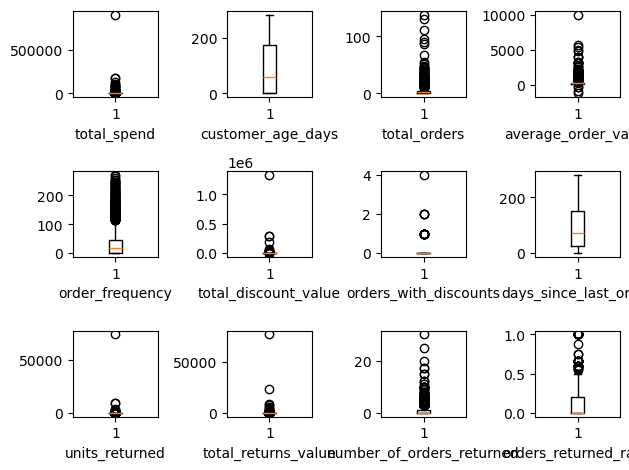

In [48]:
# Investigating & Cleaning Outliers

features = ['total_spend', 'customer_age_days', 'total_orders',
            'average_order_value', 'order_frequency', 'total_discount_value',
            'orders_with_discounts', 'days_since_last_order', 'units_returned',
            'total_returns_value', 'number_of_orders_returned', 'orders_returned_ratio']

df[features] = df[features].fillna(0)


def boxplots(df, features):
    figure, axes = plt.subplots(3, 4)
    axes = axes.flatten()

    i = 0
    for col in features:
        axes[i].boxplot(df[col])
        axes[i].set_xlabel(col)
        i += 1

    plt.tight_layout()
    plt.show()

boxplots(df, features)

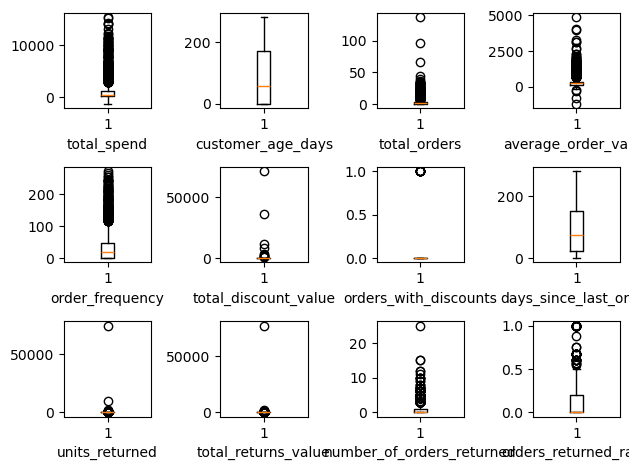

In [49]:
# Remove extreme outliers
df = df[df['total_spend'] < df['total_spend'].quantile(0.99)]
boxplots(df, features)

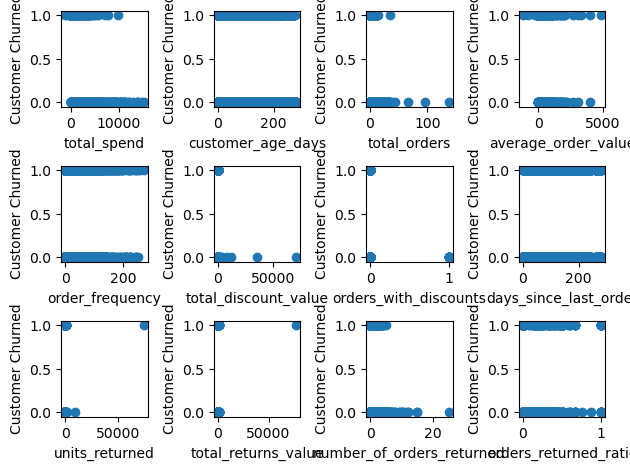

In [50]:
# Split data into train and test
from sklearn.model_selection import train_test_split

# Convert dataframe into Numpy array
X = df[features].to_numpy()
y = df['customer_churned'].to_numpy()

# Split data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2, shuffle=True)

m,n = X_train.shape

figure, axes = plt.subplots(3, 4)
axes = axes.flatten()

for i in range(n):
    axes[i].scatter(X_train[:,i], y_train)
    axes[i].set_xlabel(features[i])
    axes[i].set_ylabel('Customer Churned')

plt.tight_layout()
plt.show()

# Logistic Regression
Running the model

Accuracy: 0.6770833333333334
Actual: [1 1 0 ... 0 0 0]
Predicted: [1 1 0 ... 0 0 0]

total_spend: -0.520196997136226
customer_age_days: -0.42516562800082264
total_orders: -0.6192766412758068
average_order_value: 0.10260720937183909
order_frequency: 0.17274492880780526
total_discount_value: -0.05939525310190114
orders_with_discounts: -0.2763408626266818
days_since_last_order: 0.2538899239548566
units_returned: 0.15281823990523977
total_returns_value: 0.5221906249823633
number_of_orders_returned: 0.06617979159257227
orders_returned_ratio: -0.0022362178607446314


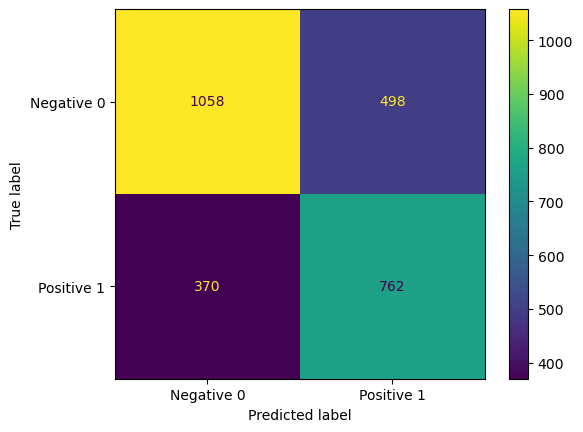

In [72]:
from sklearn import linear_model
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

scaler = StandardScaler()

# Scaling input features
X_train_scaled = scaler.fit_transform(X_train)

logr = linear_model.LogisticRegression()

logr.fit(X_train_scaled, y_train)
y_pred = logr.predict(X_train_scaled)

def evaluate(y_train, y_pred):
    print(f'Accuracy: {accuracy_score(y_train, y_pred)}')
    print(f'Actual: {y_train}\nPredicted: {y_pred}\n')

    j = 0
    for col in features:
        print(f'{col}: {logr.coef_[0][j]}')
        j += 1

    matrix = confusion_matrix(y_train, y_pred)
    cm_display = ConfusionMatrixDisplay(confusion_matrix=matrix, 
                                        display_labels= ['Negative 0', 'Positive 1'])
    cm_display.plot()

evaluate(y_train, y_pred)

### Including Polynomial Features

(2688, 455)
Accuracy: 0.7008928571428571
Actual: [1 1 0 ... 0 0 0]
Predicted: [0 1 0 ... 0 0 0]

total_spend: -0.520196997136226
customer_age_days: -0.42516562800082264
total_orders: -0.6192766412758068
average_order_value: 0.10260720937183909
order_frequency: 0.17274492880780526
total_discount_value: -0.05939525310190114
orders_with_discounts: -0.2763408626266818
days_since_last_order: 0.2538899239548566
units_returned: 0.15281823990523977
total_returns_value: 0.5221906249823633
number_of_orders_returned: 0.06617979159257227
orders_returned_ratio: -0.0022362178607446314


c:\Users\josef\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


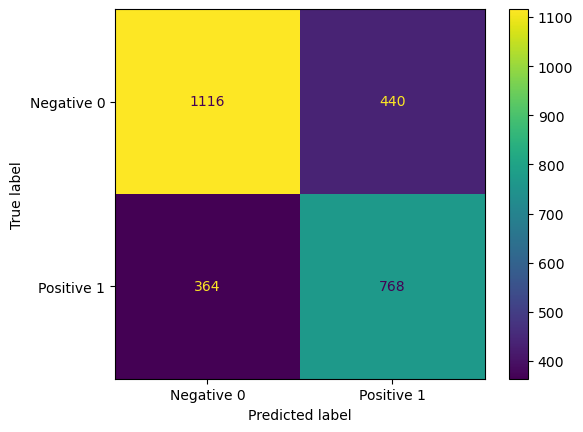

In [73]:
poly = PolynomialFeatures(degree=3)

X_train_poly = poly.fit_transform(X_train)
print(X_train_poly.shape)

X_train_poly = scaler.fit_transform(X_train_poly)

logr_poly = linear_model.LogisticRegression()
logr_poly.fit(X_train_poly, y_train)
y_pred_poly = logr_poly.predict(X_train_poly)

evaluate(y_train, y_pred_poly)

Accuracy: 0.6755952380952381
Actual: [0 1 0 0 1 1 1 1 0 0 1 1 0 0 0 0 0 1 0 1 1 1 1 0 1 0 0 0 1 1 0 0 1 0 0 0 1
 1 1 1 0 0 1 1 1 0 0 0 1 1 0 0 1 1 0 1 1 0 1 1 1 0 0 1 0 1 1 0 1 0 0 1 1 0
 1 0 1 0 0 1 1 0 0 1 0 0 0 0 0 1 1 0 1 0 1 1 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0
 1 0 1 0 0 0 1 1 0 0 1 1 0 1 1 1 0 1 1 0 1 0 1 0 0 1 0 0 1 0 0 1 1 0 0 0 0
 0 1 0 1 0 0 1 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1 0 0 1 0 0 1 0 0 1 0 0 0 0 1 1
 0 0 0 0 0 1 0 1 1 1 1 0 0 1 0 0 1 1 0 1 1 1 1 1 0 0 1 0 0 1 0 1 0 1 1 0 0
 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 1 1 0 0 1 1 0 1 1 0 1 0 1 1 0 0 0 1 1 1 0 1
 0 0 0 0 1 1 1 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1 1 0 1 0 0 0 1
 1 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 0 1 0 1
 0 0 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 0 0 1 1 0 1 1 0 0 0 1 0 1 0 0 1 0 0 0 0
 1 0 1 0 1 1 0 0 0 0 0 0 1 1 0 0 0 1 0 1 1 0 1 0 1 0 0 1 0 0 1 0 0 1 1 0 1
 1 1 1 1 0 1 1 0 1 0 1 0 1 1 0 1 0 0 0 1 0 1 1 1 1 1 0 0 0 0 1 0 1 1 1 0 0
 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 1 1 1 0 1 0 1 0 0 0 1 0 

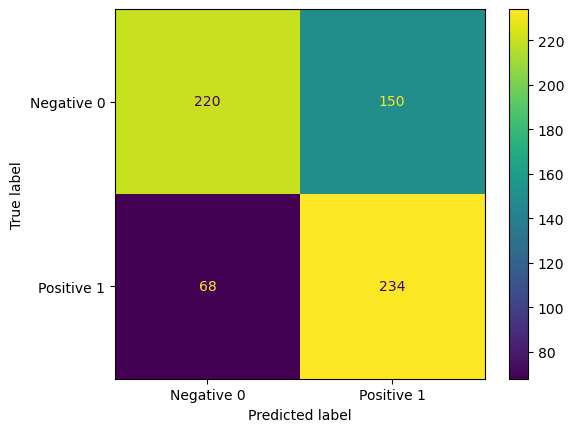

In [76]:
X_test_poly = poly.fit_transform(X_test)
X_test_poly = scaler.fit_transform(X_test_poly)
y_pred_poly = logr_poly.predict(X_test_poly)

evaluate(y_test, y_pred_poly)